C:\Users\Ranuga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Chart successfully saved to: C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Reports\Anuradhapura_All_Vegetables_Validation.png


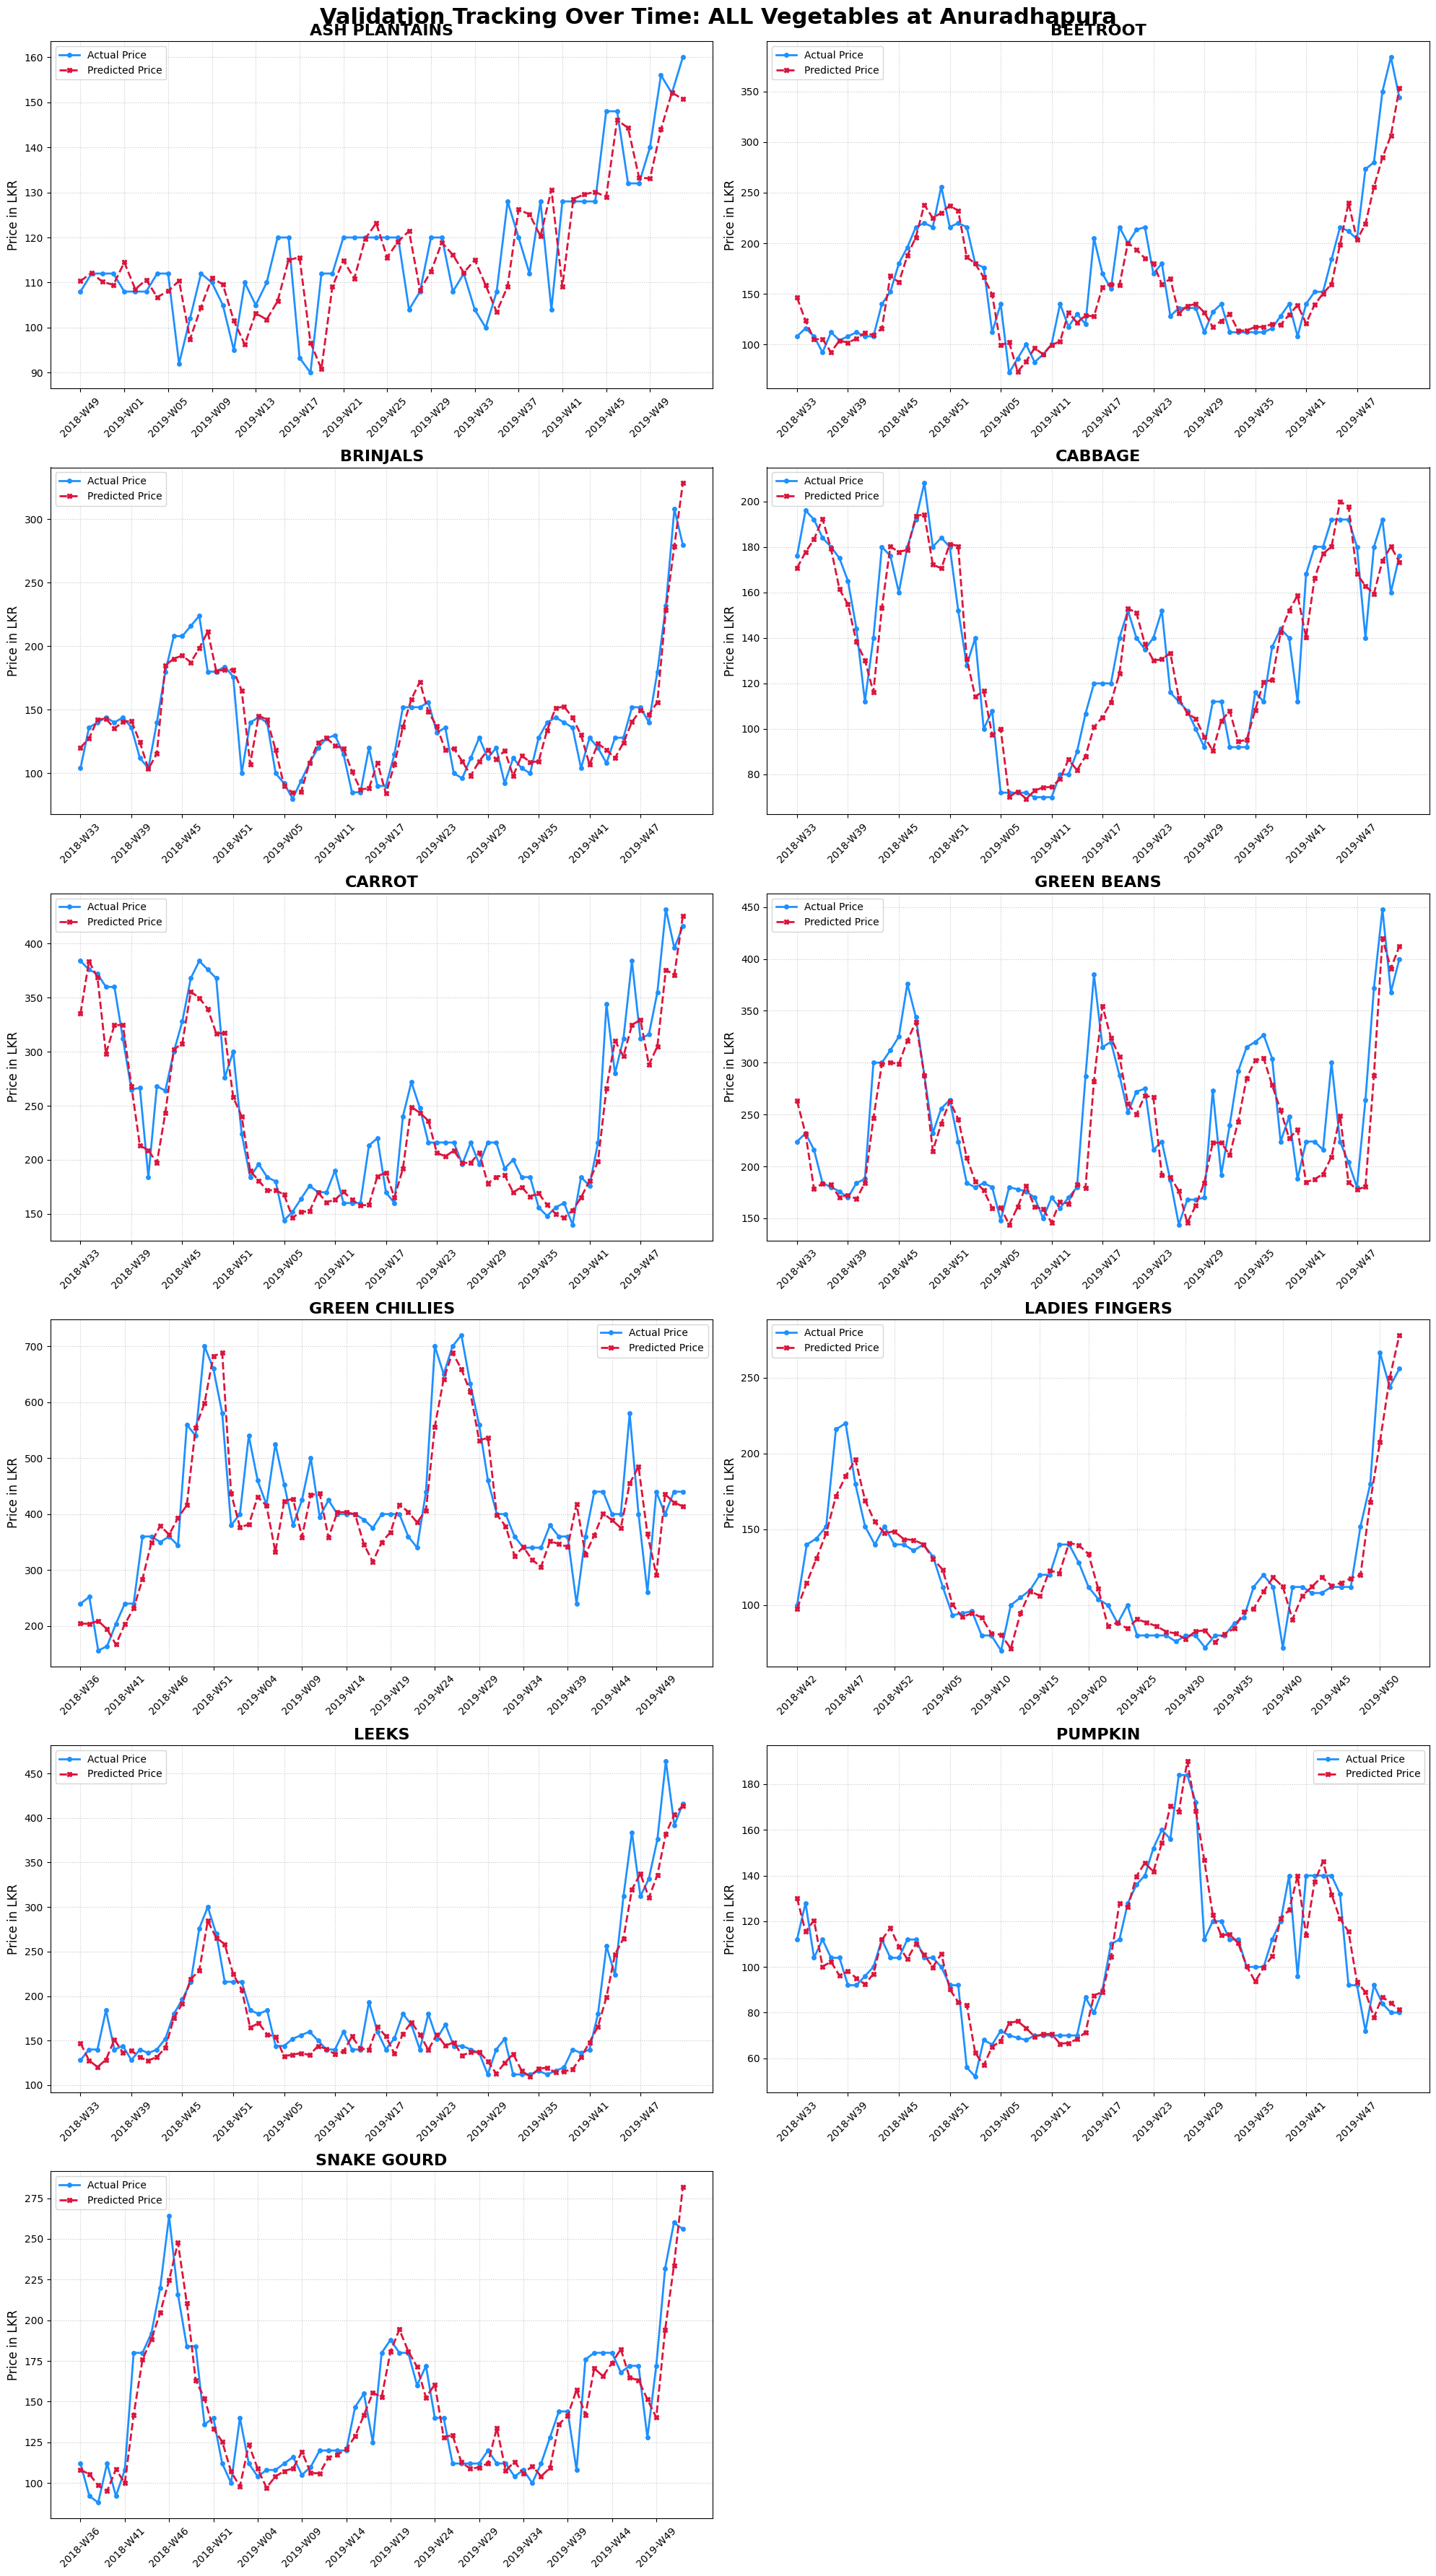

In [1]:
# ───────────────────────────────────────────────────
# Visualize Validation Tracking for ALL Vegetables in Anuradhapura
# ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder

def visualize_all_veg_anuradhapura():
    # Paths
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    output_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM'
    model_path = os.path.join(output_dir, 'Models', 'xgb_lgbm_advanced_ensemble_optuna_model.joblib')
    
    if not os.path.exists(model_path):
        print("Model not found. Please train first.")
        return

    # 1. Reconstruct Data exact same way
    df = pd.read_csv(data_path)
    df.drop(columns=['code'], inplace=True, errors='ignore')

    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum', 'mean_apparent_temperature']]
        .mean().reset_index()
        .rename(columns={'rain_sum': 'reg_rain', 'mean_apparent_temperature': 'reg_temp'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')

    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    for col in ['retail_price', 'reg_rain', 'reg_temp']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    df['retail_price_roll_4'] = df.groupby(['retail_market', 'vegetable_type'])['retail_price'].transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_4'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].transform(lambda x: x.shift(1).rolling(8).mean())
    df['farmer_price_roll_std_4'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].transform(lambda x: x.shift(1).rolling(4).std())
    df['farmer_price_pct_change_1'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']
    df['retail_price_momentum_1_4'] = df['retail_price_lag_1'] / (df['retail_price_lag_4'] + 1e-5)
    df['farmer_price_momentum_1_4'] = df['mean_farmer_price_lag_1'] / (df['mean_farmer_price_lag_4'] + 1e-5)

    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8', 'farmer_price_roll_8', 'retail_price_momentum_1_4']).copy()

    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        df_ready[f'{col}_enc'] = LabelEncoder().fit_transform(df_ready[col].astype(str))

    # Re-apply strict 80/20 train/test split
    test_list = []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        test_list.append(group.iloc[split:])
    test_df = pd.concat(test_list)

    # 2. Predict
    bundle = joblib.load(model_path)
    X_test = test_df[bundle['features']]
    
    pred_xgb = np.expm1(bundle['xgb'].predict(X_test))
    pred_lgb = np.expm1(bundle['lgb'].predict(X_test))
    final_preds = (bundle['weights']['xgb'] * pred_xgb) + (bundle['weights']['lgb'] * pred_lgb)
    
    test_df['predicted_price'] = final_preds

    # 3. Filter just Anuradhapura
    anu_df = test_df[test_df['retail_market'] == 'Anuradhapura'].copy()
    anu_df = anu_df.sort_values(['vegetable_type', 'year', 'week_num'])
    anu_df['Time'] = anu_df['year'].astype(str) + '-W' + anu_df['week_num'].astype(str).str.zfill(2)

    vegetables = anu_df['vegetable_type'].unique()
    num_vegs = len(vegetables)
    
    # Create Subplots
    cols = 2
    rows = math.ceil(num_vegs / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
    fig.suptitle('Validation Tracking Over Time: ALL Vegetables at Anuradhapura', fontsize=22, fontweight='bold', y=0.99)
    
    axes = axes.flatten()

    for i, veg in enumerate(vegetables):
        ax = axes[i]
        v_df = anu_df[anu_df['vegetable_type'] == veg]
        
        ax.plot(v_df['Time'], v_df['retail_price'], 
                marker='o', markersize=4, linestyle='-', color='dodgerblue', linewidth=2, label='Actual Price')
        
        ax.plot(v_df['Time'], v_df['predicted_price'], 
                marker='X', markersize=5, linestyle='--', color='crimson', linewidth=2, label='Predicted Price')
        
        ax.set_title(veg, fontsize=16, fontweight='bold')
        ax.set_ylabel('Price in LKR', fontsize=12)
        
        ticks = np.arange(0, len(v_df), max(1, len(v_df)//12))
        ax.set_xticks(ticks)
        ax.set_xticklabels(v_df['Time'].iloc[ticks], rotation=45)
        
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend()

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    
    # Save the huge layout to Reports
    chart_dir = os.path.join(output_dir, 'Reports')
    os.makedirs(chart_dir, exist_ok=True)
    chart_path = os.path.join(chart_dir, 'Anuradhapura_All_Vegetables_Validation.png')
    plt.savefig(chart_path, dpi=300, bbox_inches='tight')
    print(f"Chart successfully saved to: {chart_path}")
    
    plt.show()

if __name__ == "__main__":
    visualize_all_veg_anuradhapura()